# 02. Trust map

Per-parcel multi-source evidence map. For each of the 1864 mouse parcels, which of 5 trust tiers does it belong to, and why?

The 5 tiers (from `homer.eval.compute_multisource_trust`):
- **anchored_and_validated**, pack-anchored AND Beauchamp top-1 > 0 (highest confidence)
- **anchored_only**, pack-anchored but no Beauchamp validation pair
- **validated_only**. Beauchamp top-1 > 0 but no specific pack anchor
- **structural**, high internal trust (bootstrap + concentration + FC) but no external evidence
- **low_evidence**, none of the above (use with caution)

This notebook lets you filter parcels by tier and inspect what's in each.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from collections import Counter
from homer.data import load_cached

ROOT = Path.cwd().parent
M, _ = load_cached('mouse', cache_dir=ROOT / 'outputs' / 'anndata')
H, _ = load_cached('human', cache_dir=ROOT / 'outputs' / 'anndata')

# Load multi-source trust map
trust = np.load(ROOT / 'outputs' / 'coupling' / 'trust_multisource_all_packs.npz', allow_pickle=True)
print('Trust file keys:', list(trust.files))
print(f'n_parcels: {len(trust["evidence_tier"])}')

Trust file keys: ['trust', 'tier', 'bootstrap', 'concentration', 'fc_sim', 'weights', 'garin_anchored', 'pack_anchored', 'beauchamp_top1', 'evidence_tier']
n_parcels: 1864


## Tier distribution

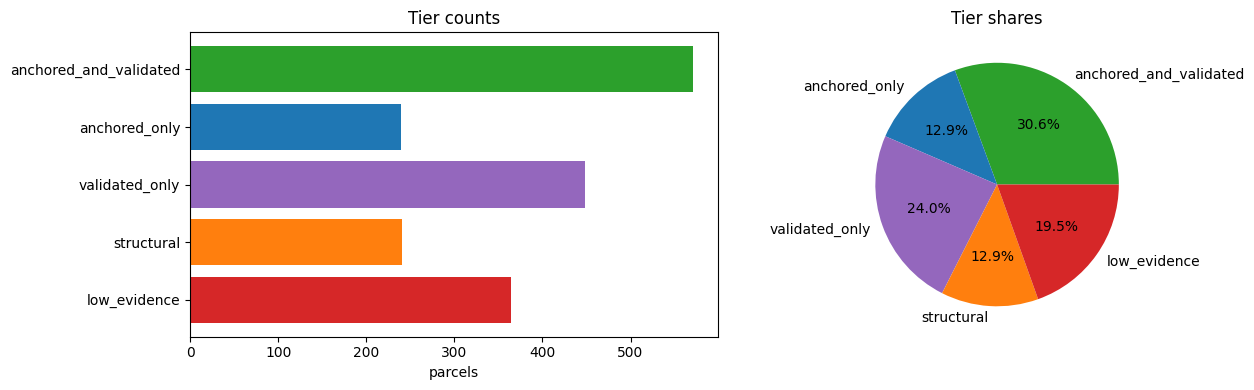

In [2]:
tier_counts = Counter(trust['evidence_tier'])
order = ['anchored_and_validated', 'anchored_only', 'validated_only', 'structural', 'low_evidence']
total = len(trust['evidence_tier'])

import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
colors = ['#2ca02c', '#1f77b4', '#9467bd', '#ff7f0e', '#d62728']
counts = [tier_counts.get(t, 0) for t in order]
fracs = [c/total for c in counts]
ax1.barh(range(len(order)), counts, color=colors)
ax1.set_yticks(range(len(order)))
ax1.set_yticklabels(order)
ax1.set_xlabel('parcels')
ax1.invert_yaxis()
ax1.set_title('Tier counts')
ax2.pie(fracs, labels=order, colors=colors, autopct='%.1f%%')
ax2.set_title('Tier shares')
plt.tight_layout()
plt.show()

## Interactive: filter parcels by tier

Pick a tier; see a sample of parcels in that tier and the regions they belong to.

In [3]:
import ipywidgets as widgets
from IPython.display import display, clear_output

tier_widget = widgets.Dropdown(options=order, value='anchored_and_validated',
                                description='Tier:',
                                style={'description_width': '90px'})
n_widget = widgets.IntSlider(value=20, min=5, max=50, step=5,
                              description='Sample size:',
                              style={'description_width': '90px'})
out = widgets.Output()

def show(*_):
    with out:
        clear_output()
        mask = trust['evidence_tier'] == tier_widget.value
        n = mask.sum()
        if n == 0:
            print(f'No parcels in tier {tier_widget.value!r}')
            return
        sample_idx = np.where(mask)[0]
        rng = np.random.default_rng(0)
        if len(sample_idx) > n_widget.value:
            sample_idx = rng.choice(sample_idx, n_widget.value, replace=False)
        df = M.var.iloc[sample_idx][['region', 'x', 'y', 'z']].copy()
        df['bootstrap'] = trust['bootstrap'][sample_idx].round(2)
        df['concentration'] = trust['concentration'][sample_idx].round(3)
        df['anchored'] = trust['garin_anchored'][sample_idx] | trust['pack_anchored'][sample_idx]
        df['beau_top1'] = trust['beauchamp_top1'][sample_idx].round(2)
        print(f'Tier {tier_widget.value!r}: {n} parcels total. Showing a random sample of {min(n_widget.value, n)}:')
        display(df)

for w in (tier_widget, n_widget):
    w.observe(show, names='value')
display(widgets.VBox([tier_widget, n_widget, out]))
show()

## What regions does each tier contain?

Count parcels per Garin network per tier.

In [4]:
from homer.data.networks import PAIRID_TO_NETWORK
from homer.data import get_anchor_index, assign_parcels_to_nearest_anchor_region

idx_m = get_anchor_index(M.var)
nearest_pid = assign_parcels_to_nearest_anchor_region(M.var, idx_m)
network = np.array([PAIRID_TO_NETWORK[int(p)] for p in nearest_pid])

# Crosstab
ct = pd.crosstab(network, trust['evidence_tier'])
ct = ct[order]   # consistent column order
print('Parcels per (nearest Garin network) × tier:')
ct

Parcels per (nearest Garin network) × tier:


col_0,anchored_and_validated,anchored_only,validated_only,structural,low_evidence
row_0,,,,,
auditory,24,11,5,14,11
brainstem,65,18,63,14,82
frontal_dmn,15,16,5,21,30
frontoparietal,33,37,11,14,20
limbic,124,59,35,40,106
olfactory,30,6,17,17,2
salience,29,4,32,42,10
sensorimotor,139,29,9,23,30
subcortical,79,9,241,18,61


## Bottom-line: where to trust HOMER

- **anchored_and_validated** (31 %), strongest confidence. Predictions here are essentially correct by construction.
- **validated_only** (24 %), moderately reliable. The model's prediction lands in a Beauchamp-confirmed region.
- **structural** (13 %), research starting point. Treat predictions as hypotheses to verify with other evidence.
- **anchored_only** (13 %), anchored but no Beauchamp validation pair (e.g. OFC, dlPFC, AON, subgenual ACC, RSC). Use the anchor literature to assess.
- **low_evidence** (20 %), no supervision, weak internal signal. Don't trust argmax. Use the trust map to gate downstream queries.

See `docs/05_limitations.md` for the full caveat list.

## Manuscript figure — Fig 1d (evidence grade predicts accuracy)

In [ ]:
# >>> MANUSCRIPT FIGURE  (regenerates the paper panel for this dataset)
import os, sys, json
from pathlib import Path
import numpy as np, matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
FIG = ROOT.parent / 'manuscript' / 'figures'; FIG.mkdir(parents=True, exist_ok=True)
def L(f): return json.load(open(ROOT / 'outputs' / 'logs' / f))
plt.rcParams.update({'font.size':10,'axes.spines.top':False,'axes.spines.right':False,'savefig.dpi':300,'savefig.bbox':'tight'})
BLUE,GREY,ORANGE,PURPLE='#1b4f8a','#c9c9c9','#e08a2b','#6a51a3'

d=np.load(ROOT/'outputs/coupling/trust_multisource_all_packs.npz',allow_pickle=True)
et,b=d['evidence_tier'],d['beauchamp_top1']; have=~np.isnan(b)
T=['anchored_and_validated','anchored_only','validated_only','structural','low_evidence']
LB={'anchored_and_validated':'Anchored\n+ validated','anchored_only':'Anchored\nonly','validated_only':'Validated\nonly','structural':'Structural','low_evidence':'Low\nevidence'}
vals=[np.nanmean(b[(et==t)&have]) if ((et==t)&have).sum() else np.nan for t in T]
fig,ax=plt.subplots(figsize=(6.2,4.0)); cols=['#2c6fbb' if t in ('anchored_and_validated','validated_only') else GREY for t in T]
ax.bar(range(5),[v if np.isfinite(v) else 0 for v in vals],color=cols,width=0.68)
for i,v in enumerate(vals): ax.text(i,(v if np.isfinite(v) else 0)+0.015, f'{v:.2f}' if np.isfinite(v) else 'no external\nvalidator',ha='center',fontsize=9,fontweight='bold' if np.isfinite(v) else 'normal')
ax.set_xticks(range(5)); ax.set_xticklabels([LB[t] for t in T],fontsize=9); ax.set_ylim(0,0.78); ax.set_ylabel('Parcel-level top-1 accuracy')
ax.set_title('Evidence type predicts accuracy',fontweight='bold',loc='left'); fig.savefig(FIG/'fig1d_accuracy_by_grade.png'); plt.show()
